# Visualização da Escala Ordinal de Notas à Imprensa do MRE

Este notebook gera visualizações gráficas a partir do arquivo de correção da escala ordinal:

`resultados/verificacoes-ordinais/correcao_escala-opencode-hy3-2026-08-14.json`

**Escala (1 a 5):** Soberania Digital ↔ Baixa Intervenção Estatal

| Nota | Descrição |
|------|-----------|
| 1 | Soberania Digital |
| 2 | Predominantemente Soberanista |
| 3 | Modelo Misto |
| 4 | Predominantemente Liberal |
| 5 | Baixa Intervenção Estatal |

As configurações de cores (`cores_escala`) podem ser ajustadas para refletir o gradiente da escala.


In [1]:
import json
import datetime as dt
from collections import Counter, defaultdict

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# Caminho do arquivo de dados
ARQUIVO = "/workspaces/governanca-digital_mre/agente-classificador-adequacao/resultados/verificacoes-ordinais/correcao_escala-opencode-hy3-2026-08-14.json"

with open(ARQUIVO, encoding="utf-8") as f:
    dados = json.load(f)

print(f"Total de notas carregadas: {len(dados)}")
print(f"Colunas: {list(dados[0].keys())}")

# Ordem e rótulos da escala
ORDENS = [1, 2, 3, 4, 5]
ROTULOS = {
    1: "1 - Soberania Digital",
    2: "2 - Pred. Soberanista",
    3: "3 - Modelo Misto",
    4: "4 - Pred. Liberal",
    5: "5 - Baixa Intervenção",
}

# Cores: gradiente do polo soberanista (azul) ao polo liberal (vermelho/laranja)
cores_escala = ["#1f4e79", "#2e75b6", "#bf9000", "#c55a11", "#a62019"]
cmap = LinearSegmentedColormap.from_list("escala", cores_escala, N=5)

plt.rcParams.update({"figure.figsize": (9, 5), "font.size": 11})


Total de notas carregadas: 116
Colunas: ['Titulo', 'Link', 'Data', 'Nota_Original', 'Descricao_Nota_Original', 'Nota_Reavaliada', 'Descricao_Nota_Reavaliada', 'Justificativa_Original', 'Justificativa_Reavaliada', 'Passagens_Originais', 'Passagens_Reavaliadas', 'Status', 'Motivo_Alteração']


## 1. Distribuição da Nota Original

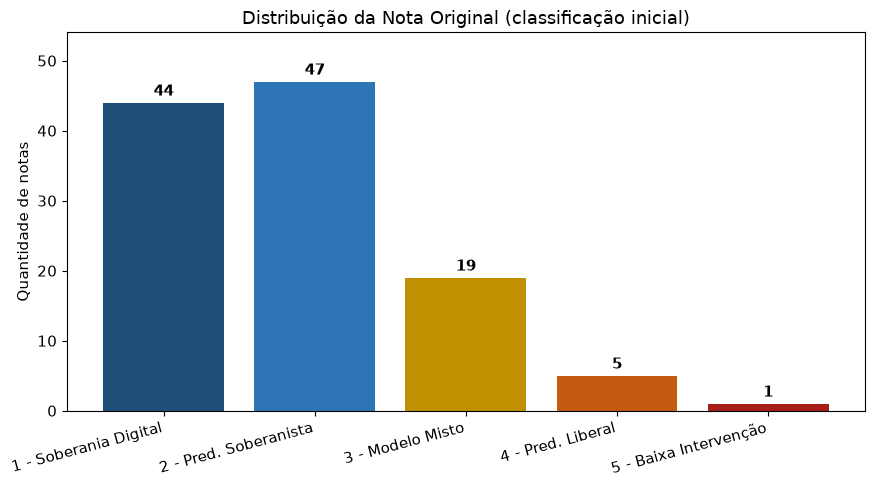

In [2]:
cont_original = Counter(int(d["Nota_Original"]) for d in dados)
vals_orig = [cont_original.get(k, 0) for k in ORDENS]

fig, ax = plt.subplots()
bars = ax.bar([ROTULOS[k] for k in ORDENS], vals_orig, color=cores_escala)
ax.set_title("Distribuição da Nota Original (classificação inicial)")
ax.set_ylabel("Quantidade de notas")
ax.set_ylim(0, max(vals_orig) * 1.15)
for b, v in zip(bars, vals_orig):
    ax.text(b.get_x() + b.get_width()/2, v + 0.5, str(v), ha="center", va="bottom", fontweight="bold")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()


## 2. Distribuição da Nota Reavaliada

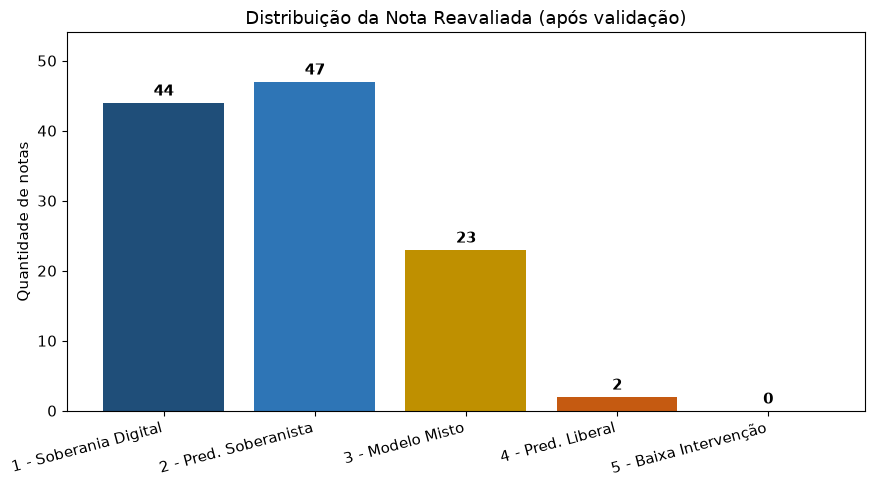

In [3]:
cont_reav = Counter(int(d["Nota_Reavaliada"]) for d in dados)
vals_reav = [cont_reav.get(k, 0) for k in ORDENS]

fig, ax = plt.subplots()
bars = ax.bar([ROTULOS[k] for k in ORDENS], vals_reav, color=cores_escala)
ax.set_title("Distribuição da Nota Reavaliada (após validação)")
ax.set_ylabel("Quantidade de notas")
ax.set_ylim(0, max(vals_reav) * 1.15)
for b, v in zip(bars, vals_reav):
    ax.text(b.get_x() + b.get_width()/2, v + 0.5, str(v), ha="center", va="bottom", fontweight="bold")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()


## 3. Comparação Original × Reavaliada

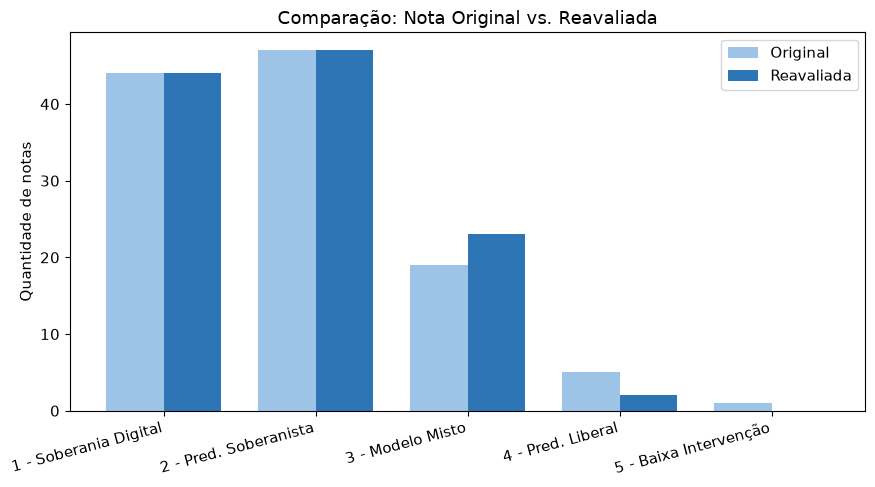

In [4]:
x = np.arange(len(ORDENS))
largura = 0.38

fig, ax = plt.subplots()
ax.bar(x - largura/2, vals_orig, largura, label="Original", color="#9dc3e6")
ax.bar(x + largura/2, vals_reav, largura, label="Reavaliada", color="#2e75b6")
ax.set_xticks(x)
ax.set_xticklabels([ROTULOS[k] for k in ORDENS], rotation=15, ha="right")
ax.set_ylabel("Quantidade de notas")
ax.set_title("Comparação: Nota Original vs. Reavaliada")
ax.legend()
plt.tight_layout()
plt.show()


## 4. Status da Validação (Mantida × Alterada)

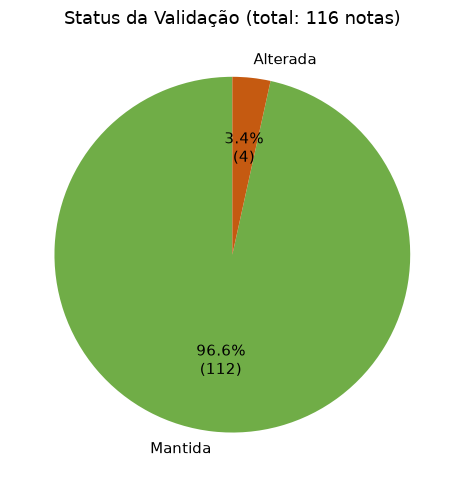

In [5]:
cont_status = Counter(d["Status"] for d in dados)
labels = list(cont_status.keys())
sizes = list(cont_status.values())

fig, ax = plt.subplots()
wedges, _, autotexts = ax.pie(
    sizes, labels=labels, autopct=lambda p: f"{p:.1f}%\n({int(round(p*sum(sizes)/100))})",
    colors=["#70ad47", "#c55a11"], startangle=90, textprops={"fontsize": 11}
)
ax.set_title(f"Status da Validação (total: {sum(sizes)} notas)")
plt.tight_layout()
plt.show()


## 5. Matriz de Transição (Original → Reavaliada)

Cada célula mostra quantas notas mudaram da nota original (linha) para a reavaliada (coluna).
A diagonal representa notas **Mantidas**.


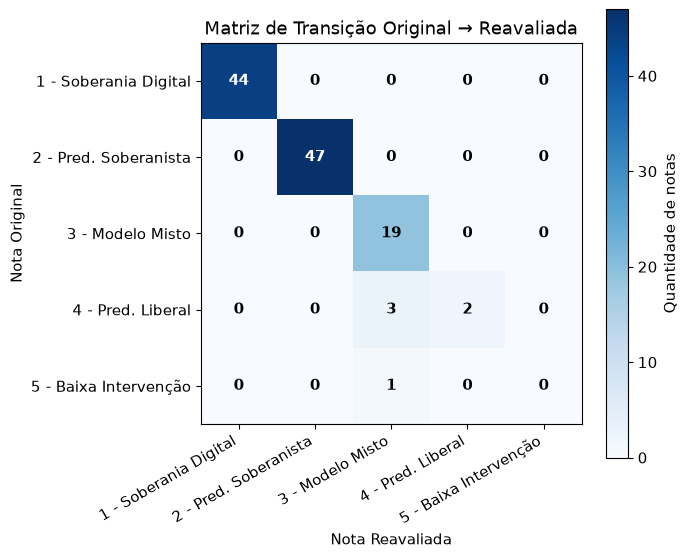

In [6]:
notas_disponiveis = sorted({int(d["Nota_Original"]) for d in dados} | {int(d["Nota_Reavaliada"]) for d in dados})
matriz = np.zeros((len(notas_disponiveis), len(notas_disponiveis)), dtype=int)
idx = {v: i for i, v in enumerate(notas_disponiveis)}
for d in dados:
    o, r = int(d["Nota_Original"]), int(d["Nota_Reavaliada"])
    matriz[idx[o], idx[r]] += 1

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(matriz, cmap="Blues")
ax.set_xticks(range(len(notas_disponiveis)))
ax.set_yticks(range(len(notas_disponiveis)))
ax.set_xticklabels([ROTULOS[k] for k in notas_disponiveis], rotation=30, ha="right")
ax.set_yticklabels([ROTULOS[k] for k in notas_disponiveis])
ax.set_xlabel("Nota Reavaliada")
ax.set_ylabel("Nota Original")
ax.set_title("Matriz de Transição Original → Reavaliada")
for i in range(len(notas_disponiveis)):
    for j in range(len(notas_disponiveis)):
        v = matriz[i, j]
        ax.text(j, i, str(v), ha="center", va="center",
                color="white" if v > matriz.max()*0.5 else "black", fontweight="bold")
fig.colorbar(im, ax=ax, label="Quantidade de notas")
plt.tight_layout()
plt.show()


## 6. Evolução Temporal da Nota Média

A nota média é calculada mês a mês a partir da `Nota_Reavaliada`, revelando tendências
ao longo do tempo no posicionamento das notas à imprensa.


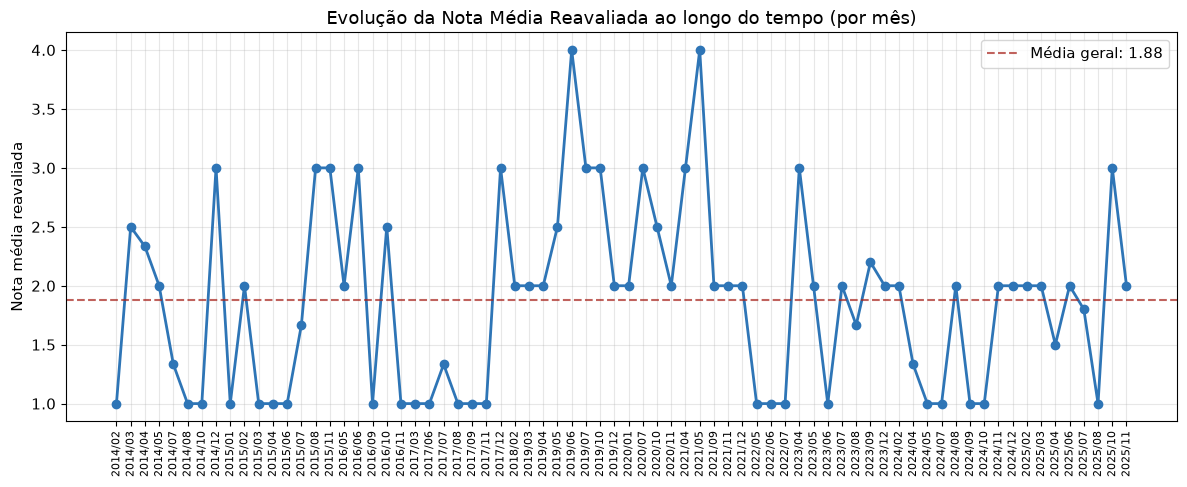

In [7]:
def parse_data(s):
    try:
        return dt.datetime.strptime(s, "%d/%m/%Y")
    except Exception:
        return None

series = defaultdict(list)
for d in dados:
    dt_obj = parse_data(d["Data"])
    if dt_obj is None:
        continue
    chave = (dt_obj.year, dt_obj.month)
    series[chave].append(int(d["Nota_Reavaliada"]))

if series:
    meses = sorted(series.keys())
    medias = [np.mean(series[m]) for m in meses]
    rotulos = [f"{a:02d}/{m:02d}" for (a, m) in meses]

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(range(len(meses)), medias, marker="o", color="#2e75b6", linewidth=2)
    ax.axhline(np.mean(medias), color="#a62019", linestyle="--", alpha=0.7,
               label=f"Média geral: {np.mean(medias):.2f}")
    ax.set_xticks(range(len(meses)))
    ax.set_xticklabels(rotulos, rotation=90, fontsize=8)
    ax.set_ylabel("Nota média reavaliada")
    ax.set_title("Evolução da Nota Média Reavaliada ao longo do tempo (por mês)")
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Não foi possível parsear as datas para a série temporal.")


## 7. Distribuição por Ano (Nota Reavaliada)

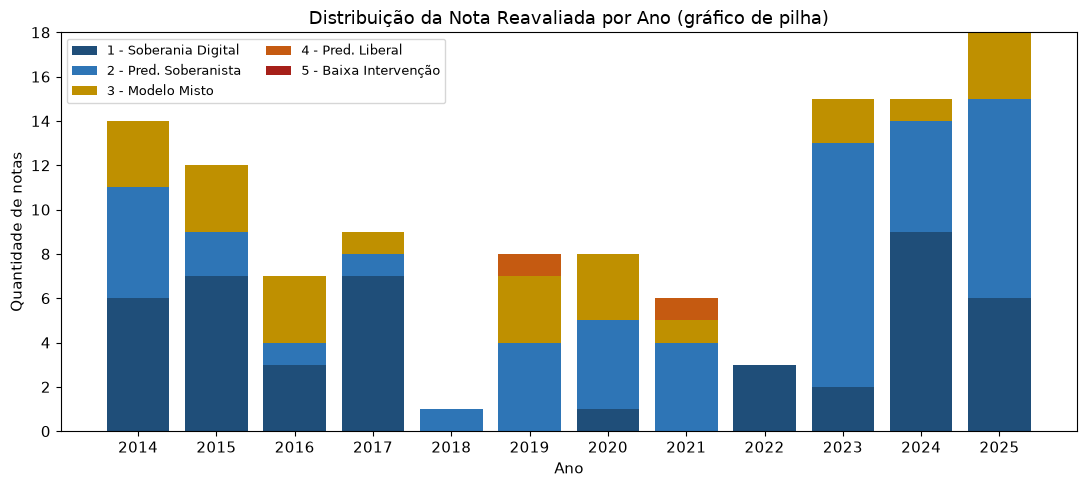

In [8]:
anos = defaultdict(lambda: Counter())
for d in dados:
    dt_obj = parse_data(d["Data"])
    if dt_obj is None:
        continue
    anos[dt_obj.year][int(d["Nota_Reavaliada"])] += 1

anos_ord = sorted(anos.keys())
bottom = np.zeros(len(anos_ord))
fig, ax = plt.subplots(figsize=(11, 5))
for k in ORDENS:
    vals = [anos[a].get(k, 0) for a in anos_ord]
    ax.bar([str(a) for a in anos_ord], vals, bottom=bottom, label=ROTULOS[k], color=cores_escala[k-1])
    bottom += np.array(vals)
ax.set_ylabel("Quantidade de notas")
ax.set_xlabel("Ano")
ax.set_title("Distribuição da Nota Reavaliada por Ano (gráfico de pilha)")
ax.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.show()


## 8. Resumo Numérico

Tabela consolidada com as principais estatísticas para referência.


In [9]:
print("=== Resumo da Escala Ordinal ===")
print(f"Total de notas: {len(dados)}")
print(f"Notas alteradas na validação: {sum(1 for d in dados if d['Status'] == 'Alterada')}")
print()
print("Distribuição ORIGINAL:")
for k in ORDENS:
    c = cont_original.get(k, 0)
    print(f"  {ROTULOS[k]:28s}: {c:3d} ({100*c/len(dados):.1f}%)")
print()
print("Distribuição REAVALIADA:")
for k in ORDENS:
    c = cont_reav.get(k, 0)
    print(f"  {ROTULOS[k]:28s}: {c:3d} ({100*c/len(dados):.1f}%)")
print()
if series:
    print(f"Nota média reavaliada (geral): {np.mean(medias):.3f}")


=== Resumo da Escala Ordinal ===
Total de notas: 116
Notas alteradas na validação: 4

Distribuição ORIGINAL:
  1 - Soberania Digital       :  44 (37.9%)
  2 - Pred. Soberanista       :  47 (40.5%)
  3 - Modelo Misto            :  19 (16.4%)
  4 - Pred. Liberal           :   5 (4.3%)
  5 - Baixa Intervenção       :   1 (0.9%)

Distribuição REAVALIADA:
  1 - Soberania Digital       :  44 (37.9%)
  2 - Pred. Soberanista       :  47 (40.5%)
  3 - Modelo Misto            :  23 (19.8%)
  4 - Pred. Liberal           :   2 (1.7%)
  5 - Baixa Intervenção       :   0 (0.0%)

Nota média reavaliada (geral): 1.877
